<a href="https://colab.research.google.com/github/pc11837/Classification/blob/main/multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

df = pd.read_csv("multiclass_classification_dataset_500_samples.csv")

In [ ]:
print(df.head())
print(df.info())

   Study_Hours  Attendance_Percentage  Assignment_Score  Internal_Marks  \
0        22.48                  84.26             86.79           76.68   
1        19.31                  94.09             81.10           56.73   
2        23.24                  61.01             70.72           52.73   
3        27.62                  80.63             62.24           64.95   
4        18.83                  68.49             78.38           62.45   

  Participation Internet_Access Previous_Grade  Performance_Level  
0        Medium             Yes              B                  1  
1           Low             Yes              B                  1  
2        Medium             Yes              A                  0  
3           Low             Yes              C                  0  
4          High             Yes              B                  0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                 Non-Null 

In [ ]:
from sklearn.preprocessing import LabelEncoder

y = df["Performance_Level"]

X = df.drop("Performance_Level", axis=1)

X = pd.get_dummies(X, drop_first=True)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "KNN": KNeighborsClassifier()
}

In [ ]:
results={}

from sklearn.metrics import accuracy_score,roc_auc_score,roc_curve

plt.figure()

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)
    acc=accuracy_score(y_test,y_pred)
    auc=roc_auc_score(y_test,y_prob,multi_class='ovr')
    results[name]=(acc,auc)
    print(name)
    print("Accuracy:",acc)
    print("AUC:",auc)
    print()

Random Forest
Accuracy: 0.83
AUC: 0.9656602907829798

Decision Tree
Accuracy: 0.79
AUC: 0.6970401493930906

Logistic Regression
Accuracy: 1.0
AUC: 1.0



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:59:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Accuracy: 0.89
AUC: 0.9817299719887954

KNN
Accuracy: 0.95
AUC: 0.9929319727891156



<Figure size 640x480 with 0 Axes>

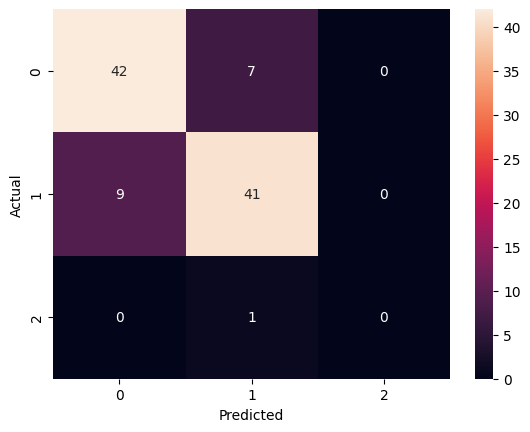

In [ ]:
from sklearn.metrics import confusion_matrix

best_model=RandomForestClassifier()
best_model.fit(X_train,y_train)
y_pred=best_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
pickle.dump(best_model,open("student_model.pkl","wb"))